In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("OptimizedKMeans").config("spark.executor.memory", "8g").config("spark.executor.cores", "4").config("spark.sql.shuffle.partitions", "200").config("spark.default.parallelism", "200").getOrCreate()


In [ ]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[4]").getOrCreate()

# Read json file
news_df=spark.read.json("/content/gdrive/MyDrive/news/News_Category_Dataset_v3.json")
news_df.toPandas()

,authors,category,date,headline,link,short_description
0,"Carla K. Johnson, AP",U.S. NEWS,2022-09-23,Over 4 Million Americans Roll Up Sleeves For O...,https://www.huffpost.com/entry/covid-boosters-...,Health experts said it is too early to predict...
1,Mary Papenfuss,U.S. NEWS,2022-09-23,"American Airlines Flyer Charged, Banned For Li...",https://www.huffpost.com/entry/american-airlin...,He was subdued by passengers and crew when he ...
2,Elyse Wanshel,COMEDY,2022-09-23,23 Of The Funniest Tweets About Cats And Dogs ...,https://www.huffpost.com/entry/funniest-tweets...,"""Until you have a dog you don't understand wha..."
3,Caroline Bologna,PARENTING,2022-09-23,The Funniest Tweets From Parents This Week (Se...,https://www.huffpost.com/entry/funniest-parent...,"""Accidentally put grown-up toothpaste on my to..."
4,Nina Golgowski,U.S. NEWS,2022-09-22,Woman Who Called Cops On Black Bird-Watcher Lo...,https://www.huffpost.com/entry/amy-cooper-lose...,Amy Cooper accused investment firm Franklin Te...
...,...,...,...,...,...,...
209522,"Reuters, Reuters",TECH,2012-01-28,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,https://www.huffingtonpost.com/entry/rim-ceo-t...,Verizon Wireless and AT&T are already promotin...
209523,,SPORTS,2012-01-28,Maria Sharapova Stunned By Victoria Azarenka I...,https://www.huffingtonpost.com/entry/maria-sha...,"Afterward, Azarenka, more effusive with the pr..."
209524,,SPORTS,2012-01-28,"Giants Over Patriots, Jets Over Colts Among M...",https://www.huffingtonpost.com/entry/super-bow...,"Leading up to Super Bowl XLVI, the most talked..."
209525,,SPORTS,2012-01-28,Aldon Smith Arrested: 49ers Linebacker Busted ...,https://www.huffingtonpost.com/entry/aldon-smi...,CORRECTION: An earlier version of this story i...


In [ ]:
news_df.printSchema()

root
 |-- authors: string (nullable = true)
 |-- category: string (nullable = true)
 |-- date: string (nullable = true)
 |-- headline: string (nullable = true)
 |-- link: string (nullable = true)
 |-- short_description: string (nullable = true)



In [ ]:
# انتخاب ستون‌های مورد نیاز
news_df = news_df.select("headline", "category")

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.sql.functions import col

# 1. Tokenization (جدا کردن کلمات)
tokenizer = Tokenizer(inputCol="headline", outputCol="tokens")
tokenized_df = tokenizer.transform(news_df)

In [ ]:
tokenized_df.toPandas()

,headline,category,tokens
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,"[over, 4, million, americans, roll, up, sleeve..."
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,"[american, airlines, flyer, charged,, banned, ..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"[23, of, the, funniest, tweets, about, cats, a..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,"[the, funniest, tweets, from, parents, this, w..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,"[woman, who, called, cops, on, black, bird-wat..."
...,...,...,...
209522,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,"[rim, ceo, thorsten, heins', 'significant', pl..."
209523,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,"[maria, sharapova, stunned, by, victoria, azar..."
209524,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,"[giants, over, patriots,, jets, over, colts, a..."
209525,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,"[aldon, smith, arrested:, 49ers, linebacker, b..."


In [ ]:
# 2. Stop Words حذف
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
filtered_df = remover.transform(tokenized_df)

In [ ]:
filtered_df.toPandas()

In [ ]:
# 3. Bag of Words (CountVectorizer)
cv = CountVectorizer(inputCol="filtered_tokens", outputCol="BoW_features")
cv_model = cv.fit(filtered_df)
BoW_df = cv_model.transform(filtered_df)

In [ ]:
BoW_df.toPandas()

,headline,category,tokens,filtered_tokens,BoW_features
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,"[over, 4, million, americans, roll, up, sleeve...","[4, million, americans, roll, sleeves, omicron...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,"[american, airlines, flyer, charged,, banned, ...","[american, airlines, flyer, charged,, banned, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"[23, of, the, funniest, tweets, about, cats, a...","[23, funniest, tweets, cats, dogs, week, (sept...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,"[the, funniest, tweets, from, parents, this, w...","[funniest, tweets, parents, week, (sept., 17-23)]","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,"[woman, who, called, cops, on, black, bird-wat...","[woman, called, cops, black, bird-watcher, los...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...
209522,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,"[rim, ceo, thorsten, heins', 'significant', pl...","[rim, ceo, thorsten, heins', 'significant', pl...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
209523,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,"[maria, sharapova, stunned, by, victoria, azar...","[maria, sharapova, stunned, victoria, azarenka...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
209524,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,"[giants, over, patriots,, jets, over, colts, a...","[giants, patriots,, jets, colts, among, , impr...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
209525,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,"[aldon, smith, arrested:, 49ers, linebacker, b...","[aldon, smith, arrested:, 49ers, linebacker, b...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF

hashingTF = HashingTF(inputCol="filtered_tokens", outputCol="TF_Features", numFeatures=3000)
tfData = hashingTF.transform(BoW_df)


In [ ]:
idf = IDF(inputCol="TF_Features", outputCol="features")
idfModel = idf.fit(tfData)
tfidfData = idfModel.transform(tfData)


In [ ]:
tfidfData.limit(50).toPandas()

,headline,category,tokens,filtered_tokens,BoW_features,TF_Features,features
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,"[over, 4, million, americans, roll, up, sleeve...","[4, million, americans, roll, sleeves, omicron...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,"[american, airlines, flyer, charged,, banned, ...","[american, airlines, flyer, charged,, banned, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"[23, of, the, funniest, tweets, about, cats, a...","[23, funniest, tweets, cats, dogs, week, (sept...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,"[the, funniest, tweets, from, parents, this, w...","[funniest, tweets, parents, week, (sept., 17-23)]","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,"[woman, who, called, cops, on, black, bird-wat...","[woman, called, cops, black, bird-watcher, los...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,Cleaner Was Dead In Belk Bathroom For 4 Days B...,U.S. NEWS,"[cleaner, was, dead, in, belk, bathroom, for, ...","[cleaner, dead, belk, bathroom, 4, days, body,...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,Reporter Gets Adorable Surprise From Her Boyfr...,U.S. NEWS,"[reporter, gets, adorable, surprise, from, her...","[reporter, gets, adorable, surprise, boyfriend...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,Puerto Ricans Desperate For Water After Hurric...,WORLD NEWS,"[puerto, ricans, desperate, for, water, after,...","[puerto, ricans, desperate, water, hurricane, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,How A New Documentary Captures The Complexity ...,CULTURE & ARTS,"[how, a, new, documentary, captures, the, comp...","[new, documentary, captures, complexity, child...","(0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,Biden At UN To Call Russian War An Affront To ...,WORLD NEWS,"[biden, at, un, to, call, russian, war, an, af...","[biden, un, call, russian, war, affront, body'...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


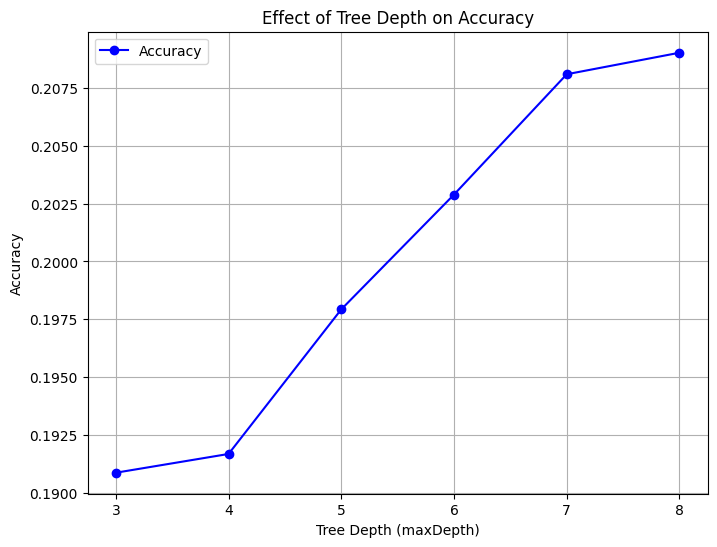

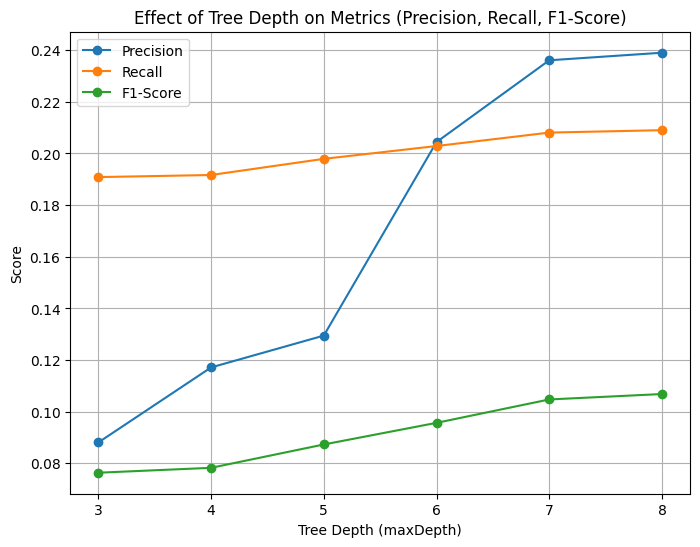

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt

# ایجاد لیبل
indexer = StringIndexer(inputCol="category", outputCol="label")
final_data = indexer.fit(tfidfData).transform(tfidfData)

# تقسیم داده‌ها به آموزش و تست
train_df, test_df = final_data.randomSplit([0.8, 0.2], seed=42)

# تعیین عمق های درخت
depths = range(3, 9)
metrics = {"accuracy": [], "precision": [], "recall": [], "f1": []}

for depth in depths:
    # تعریف مدل درخت تصمیم
    dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=depth)

    # آموزش مدل
    model = dt.fit(train_df)

    # پیش‌بینی روی داده‌های تست
    predictions = model.transform(test_df)

    # ارزیابی دقیق
    evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

    # محاسبه معیارها
    accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
    precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
    recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})
    f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

    # ذخیره نتایج
    metrics["accuracy"].append(accuracy)
    metrics["precision"].append(precision)
    metrics["recall"].append(recall)
    metrics["f1"].append(f1)

# Accuracy رسم نمودار
plt.figure(figsize=(8, 6))
plt.plot(depths, metrics["accuracy"], marker='o', linestyle='-', color='b', label="Accuracy")
plt.title("Effect of Tree Depth on Accuracy")
plt.xlabel("Tree Depth (maxDepth)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Precision, Recall, F1-Score رسم نمودار
plt.figure(figsize=(8, 6))
plt.plot(depths, metrics["precision"], marker='o', linestyle='-', label="Precision")
plt.plot(depths, metrics["recall"], marker='o', linestyle='-', label="Recall")
plt.plot(depths, metrics["f1"], marker='o', linestyle='-', label="F1-Score")
plt.title("Effect of Tree Depth on Metrics (Precision, Recall, F1-Score)")
plt.xlabel("Tree Depth (maxDepth)")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


Accuracy for maxBins 4: 0.2090318574771935
Accuracy for maxBins 8: 0.2090318574771935
Accuracy for maxBins 16: 0.2090318574771935
Accuracy for maxBins 32: 0.2090318574771935
Accuracy for maxBins 64: 0.2090318574771935
Accuracy for maxBins 128: 0.2090318574771935
Accuracy for maxBins 256: 0.2090318574771935


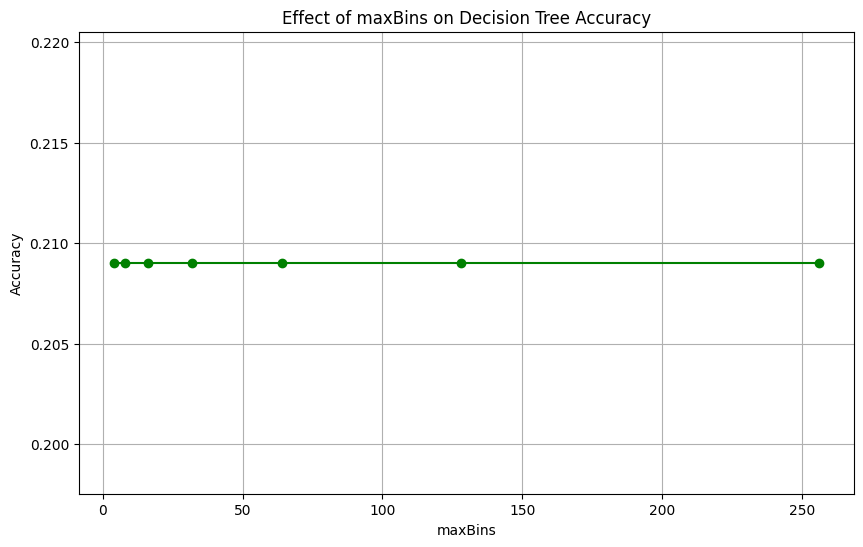

In [ ]:
# مقادیر maxBins برای آزمایش
bins = [4, 8, 16, 32, 64, 128, 256]

# عمق بهینه به دست آمده از قسمت قبل)
optimal_depth = 8

# متغیر برای ذخیره دقت‌ها
accuracies_bins = []

# maxBins آموزش مدل برای مقادیر مختلف
for max_bin in bins:
    dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", maxDepth=optimal_depth, maxBins=max_bin)
    model = dt.fit(train_df)
    predictions = model.transform(test_df)

    evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
    accuracy = evaluator.evaluate(predictions)
    accuracies_bins.append(accuracy)
    print(f"Accuracy for maxBins {max_bin}: {accuracy}")

# رسم نمودار
plt.figure(figsize=(10, 6))
plt.plot(bins, accuracies_bins, marker='o', linestyle='-', color='g')
plt.title("Effect of maxBins on Decision Tree Accuracy")
plt.xlabel("maxBins")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [ ]:
print(f"Number of cores: {spark.sparkContext.defaultParallelism}")


Number of cores: 2


numTrees=4 -> Accuracy: 0.20578401872283517, Precision: 0.21870417046399412, Recall: 0.20578401872283517, F1: 0.10304829022487866, Time: 90.61253833770752
numTrees=16 -> Accuracy: 0.1841237999713426, Precision: 0.24474500850138048, Recall: 0.1841237999713426, F1: 0.07371230023878995, Time: 88.83556795120239
numTrees=64 -> Accuracy: 0.17667287577016766, Precision: 0.22696906443520423, Recall: 0.17667287577016763, F1: 0.06199190560830413, Time: 165.87679290771484


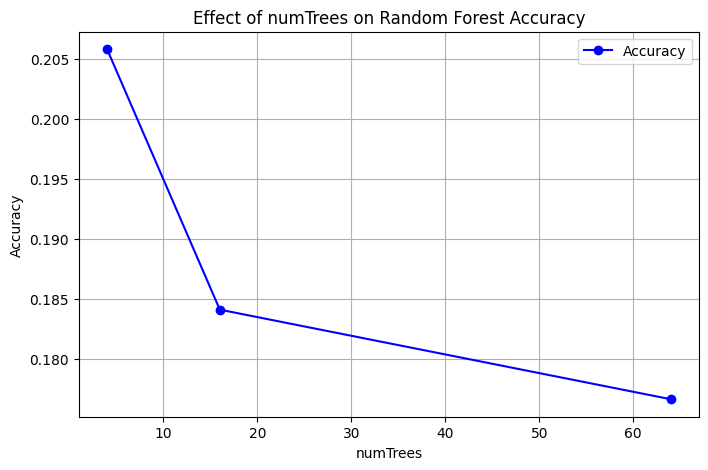

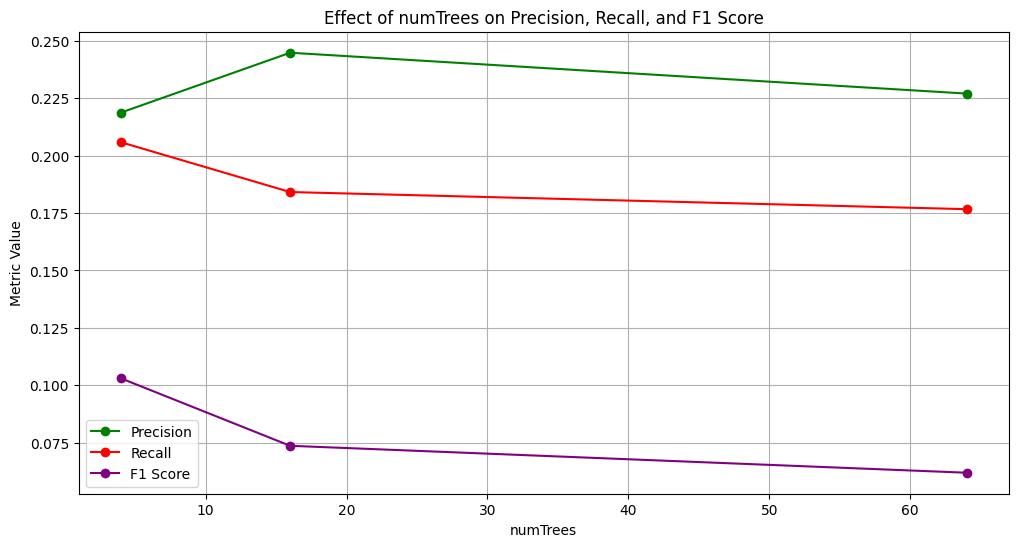

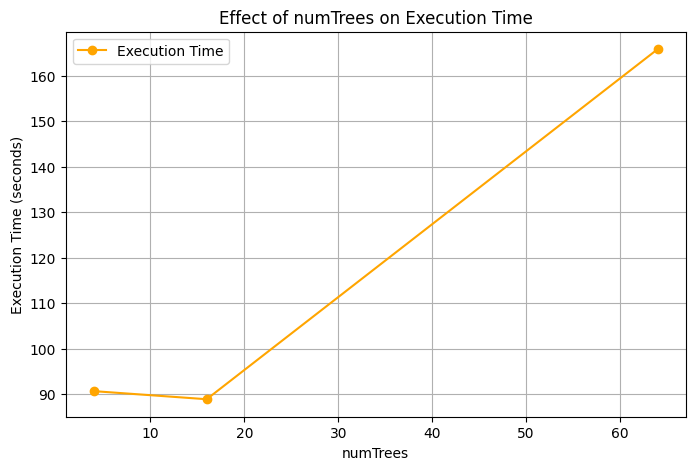

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
from time import time

# numTrees مقادیر مختلف
num_trees = [4, 16, 64]

# بهینه شده از تمرین های قبلی maxDepth  پارامتر
optimal_depth = 8

# Recall, Precision, F1 Score و Accuracy ذخیره مقادیر برای
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "execution_time": []
}

# numTrees محاسبه متریک‌ها برای هر مقدار
for trees in num_trees:
    rf = RandomForestClassifier(featuresCol="features", labelCol="label", maxDepth=optimal_depth, numTrees=trees)

    start_time = time()
    model = rf.fit(train_df)
    predictions = model.transform(test_df)
    end_time = time()

    # محاسبه متریک‌ها
    evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
    evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
    evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

    metrics["accuracy"].append(evaluator_accuracy.evaluate(predictions))
    metrics["precision"].append(evaluator_precision.evaluate(predictions))
    metrics["recall"].append(evaluator_recall.evaluate(predictions))
    metrics["f1"].append(evaluator_f1.evaluate(predictions))
    metrics["execution_time"].append(end_time - start_time)

    print(f"numTrees={trees} -> Accuracy: {metrics['accuracy'][-1]}, Precision: {metrics['precision'][-1]}, Recall: {metrics['recall'][-1]}, F1: {metrics['f1'][-1]}, Time: {metrics['execution_time'][-1]}")

# Accuracy رسم نمودار
plt.figure(figsize=(8, 5))
plt.plot(num_trees, metrics["accuracy"], marker='o', linestyle='-', color='b', label="Accuracy")
plt.title("Effect of numTrees on Random Forest Accuracy")
plt.xlabel("numTrees")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Precision, Recall و F1 Score رسم نمودارهای
plt.figure(figsize=(12, 6))
plt.plot(num_trees, metrics["precision"], marker='o', linestyle='-', color='g', label="Precision")
plt.plot(num_trees, metrics["recall"], marker='o', linestyle='-', color='r', label="Recall")
plt.plot(num_trees, metrics["f1"], marker='o', linestyle='-', color='purple', label="F1 Score")
plt.title("Effect of numTrees on Precision, Recall, and F1 Score")
plt.xlabel("numTrees")
plt.ylabel("Metric Value")
plt.grid(True)
plt.legend()
plt.show()

# رسم نمودار زمان اجرا
plt.figure(figsize=(8, 5))
plt.plot(num_trees, metrics["execution_time"], marker='o', linestyle='-', color='orange', label="Execution Time")
plt.title("Effect of numTrees on Execution Time")
plt.xlabel("numTrees")
plt.ylabel("Execution Time (seconds)")
plt.grid(True)
plt.legend()
plt.show()
